# GOES GLM lightning over True Color

The Geostationary Lightning Mapper reports individual optical **flashes** with a
latitude, longitude and time. Here they are drawn on top of a True Color image.

The example is a line of afternoon thunderstorms over the central United States
on 3 October 2023 around 20:00 UTC (about 14:00 local, so there is daylight for
True Color). GOES-16 sees that region; for GOES-18 use your own files and box.

Everything is in this notebook: the folder your files are in, the box
you choose, and the whole plotting code. Change any of it and re-run.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/);
nothing is downloaded here.

**Steps:** point at your folder -> plot the whole scan -> set your box -> plot
that box.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, display
from shapely.geometry import box as shapely_box

sys.path.insert(0, "..")
import goestools as gt


In [2]:
# ---------------------------------------------------------------
# Settings come from config.yml at the repository root. Override any of them
# in the next few lines if you want a one-off change.
# ---------------------------------------------------------------
CONFIG = yaml.safe_load(open("../config.yml"))
style = CONFIG["style"]

COAST_COLOUR = style["coast_colour"]
COAST_WIDTH = style["coast_width"]
COAST_RES = style["coast_resolution"]

GRID_COLOUR = style["grid_colour"]
GRID_ALPHA = style["grid_alpha"]
GRID_STYLE = style["grid_style"]
GRID_WIDTH = style["grid_width"]

MARKER_LON = style["marker_lon"]          # None hides the marker
MARKER_LAT = style["marker_lat"]
MARKER_COLOUR = style["marker_colour"]
MARKER_SIZE = style["marker_size"]

FIG_WIDTH = style["figure_width"]
DPI = style["dpi"]
STRIDE = style["overview_stride"]         # every n-th pixel for the whole scan


In [3]:
# ---------------------------------------------------------------
# Kept here so you can change them: coastlines clipped to a box, and the
# degree labels on the axes.
# ---------------------------------------------------------------
def coastlines(west, east, south, north, resolution="10m"):
    clip = shapely_box(west, south, east, north)
    segments = []
    feature = cfeature.NaturalEarthFeature("physical", "coastline", resolution)
    for geometry in feature.intersecting_geometries([west, east, south, north]):
        piece = geometry.intersection(clip)
        for line in (piece.geoms if hasattr(piece, "geoms") else [piece]):
            if not line.is_empty and line.length > 0:
                x, y = line.xy
                segments.append((np.asarray(x), np.asarray(y)))
    return segments


def lon_label(value, _pos=None):
    v = ((value + 180) % 360) - 180
    return f"{abs(v):g}\u00b0{'E' if v >= 0 else 'W'}"


def lat_label(value, _pos=None):
    return f"{abs(value):g}\u00b0{'N' if value >= 0 else 'S'}"


def decorate(ax, west, east, south, north, left_title, when):
    """Coastlines, graticule, degree labels and the two-part header."""
    ax.grid(color=GRID_COLOUR, alpha=GRID_ALPHA, ls=GRID_STYLE, lw=GRID_WIDTH,
            zorder=1)
    for x, y in coastlines(west, east, south, north, COAST_RES):
        ax.plot(x, y, color=COAST_COLOUR, lw=COAST_WIDTH, zorder=4)
    if MARKER_LON is not None and west <= MARKER_LON <= east and south <= MARKER_LAT <= north:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR,
                ms=MARKER_SIZE, zorder=6)
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lon_label))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lat_label))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(left_title, loc="left")
    if when is not None:
        ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")


def draw_whole_scan(values, extent, gs, left_title, when, **imshow_kwargs):
    """Draw a whole scan in the satellite's own projection.

    A Full Disk really is a disk: drawing it on a flat longitude/latitude map
    would stretch it across the globe, because the disk reaches the
    antimeridian. Cartopy's Geostationary projection shows it as the satellite
    sees it, with coastlines and a graticule on top.
    """
    import cartopy.crs as ccrs

    crs = gt.cartopy_crs(gs)
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(1, 1, 1, projection=crs)
    image = ax.imshow(values, origin="upper", extent=extent, transform=crs,
                      **imshow_kwargs)
    ax.coastlines(resolution="50m", color=COAST_COLOUR, linewidth=COAST_WIDTH)
    ax.gridlines(color=GRID_COLOUR, alpha=GRID_ALPHA, linestyle=GRID_STYLE,
                 linewidth=GRID_WIDTH)
    if MARKER_LON is not None:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR,
                ms=MARKER_SIZE, transform=ccrs.PlateCarree(), zorder=6)
    ax.set_title(left_title, loc="left")
    if when is not None:
        ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")
    return fig, ax, image


def figure_for(west, east, south, north):
    height = FIG_WIDTH * (north - south) / (east - west) * 0.92
    return plt.subplots(figsize=(FIG_WIDTH, max(3.0, min(12.0, height))))


In [4]:
# This scene has no volcano, so hide the marker and set the flash style.
MARKER_LON = MARKER_LAT = None
FLASH_COLOUR = style["flash_colour"]
FLASH_SIZE = style["flash_size"]
FLASH_EDGE = style["flash_edge_width"]


## 1. Your files

Two products for the same moment: the ABI channels for True Color, and the GLM
flash files. Both come from your own download.

In [5]:
ABI_DIR = Path("..") / CONFIG["data"]["glm_abi"]
GLM_DIR = Path("..") / CONFIG["data"]["glm_flashes"]

abi_files = sorted(glob.glob(str(ABI_DIR / "*.nc")))
glm_files = sorted(glob.glob(str(GLM_DIR / "*.nc")))
print(f"ABI: {len(abi_files)} file(s) in {ABI_DIR}")
print(f"GLM: {len(glm_files)} file(s) in {GLM_DIR}")

paths = gt.find_channels(abi_files, ["C01", "C02", "C03"])
print("using:", ", ".join(paths))


ABI: 3 file(s) in ../data/glm/abi
GLM: 30 file(s) in ../data/glm/flashes
using: C01, C02, C03


## 2. Your box

GLM sees the whole disk, so this box decides which flashes are drawn as well as
the extent of the image.

In [6]:
# LON_MIN, LON_MAX, LAT_MIN, LAT_MAX
BOX = (-104.0, -97.0, 36.0, 43.0)

lon_min, lon_max, lat_min, lat_max = BOX
print("box:", BOX)


box: (-104.0, -97.0, 36.0, 43.0)


## 3. Read the flashes

Each file holds `flash_lat` and `flash_lon`. Every flash in the files you
downloaded is drawn, so the length of that download sets how much of the storm's
history appears in one frame.

In [7]:
flash_lon, flash_lat = gt.read_glm_flashes(glm_files, BOX)
print(f"{len(flash_lon)} flashes inside the box")


1056 flashes inside the box


## 4. True Color, with the flashes on top

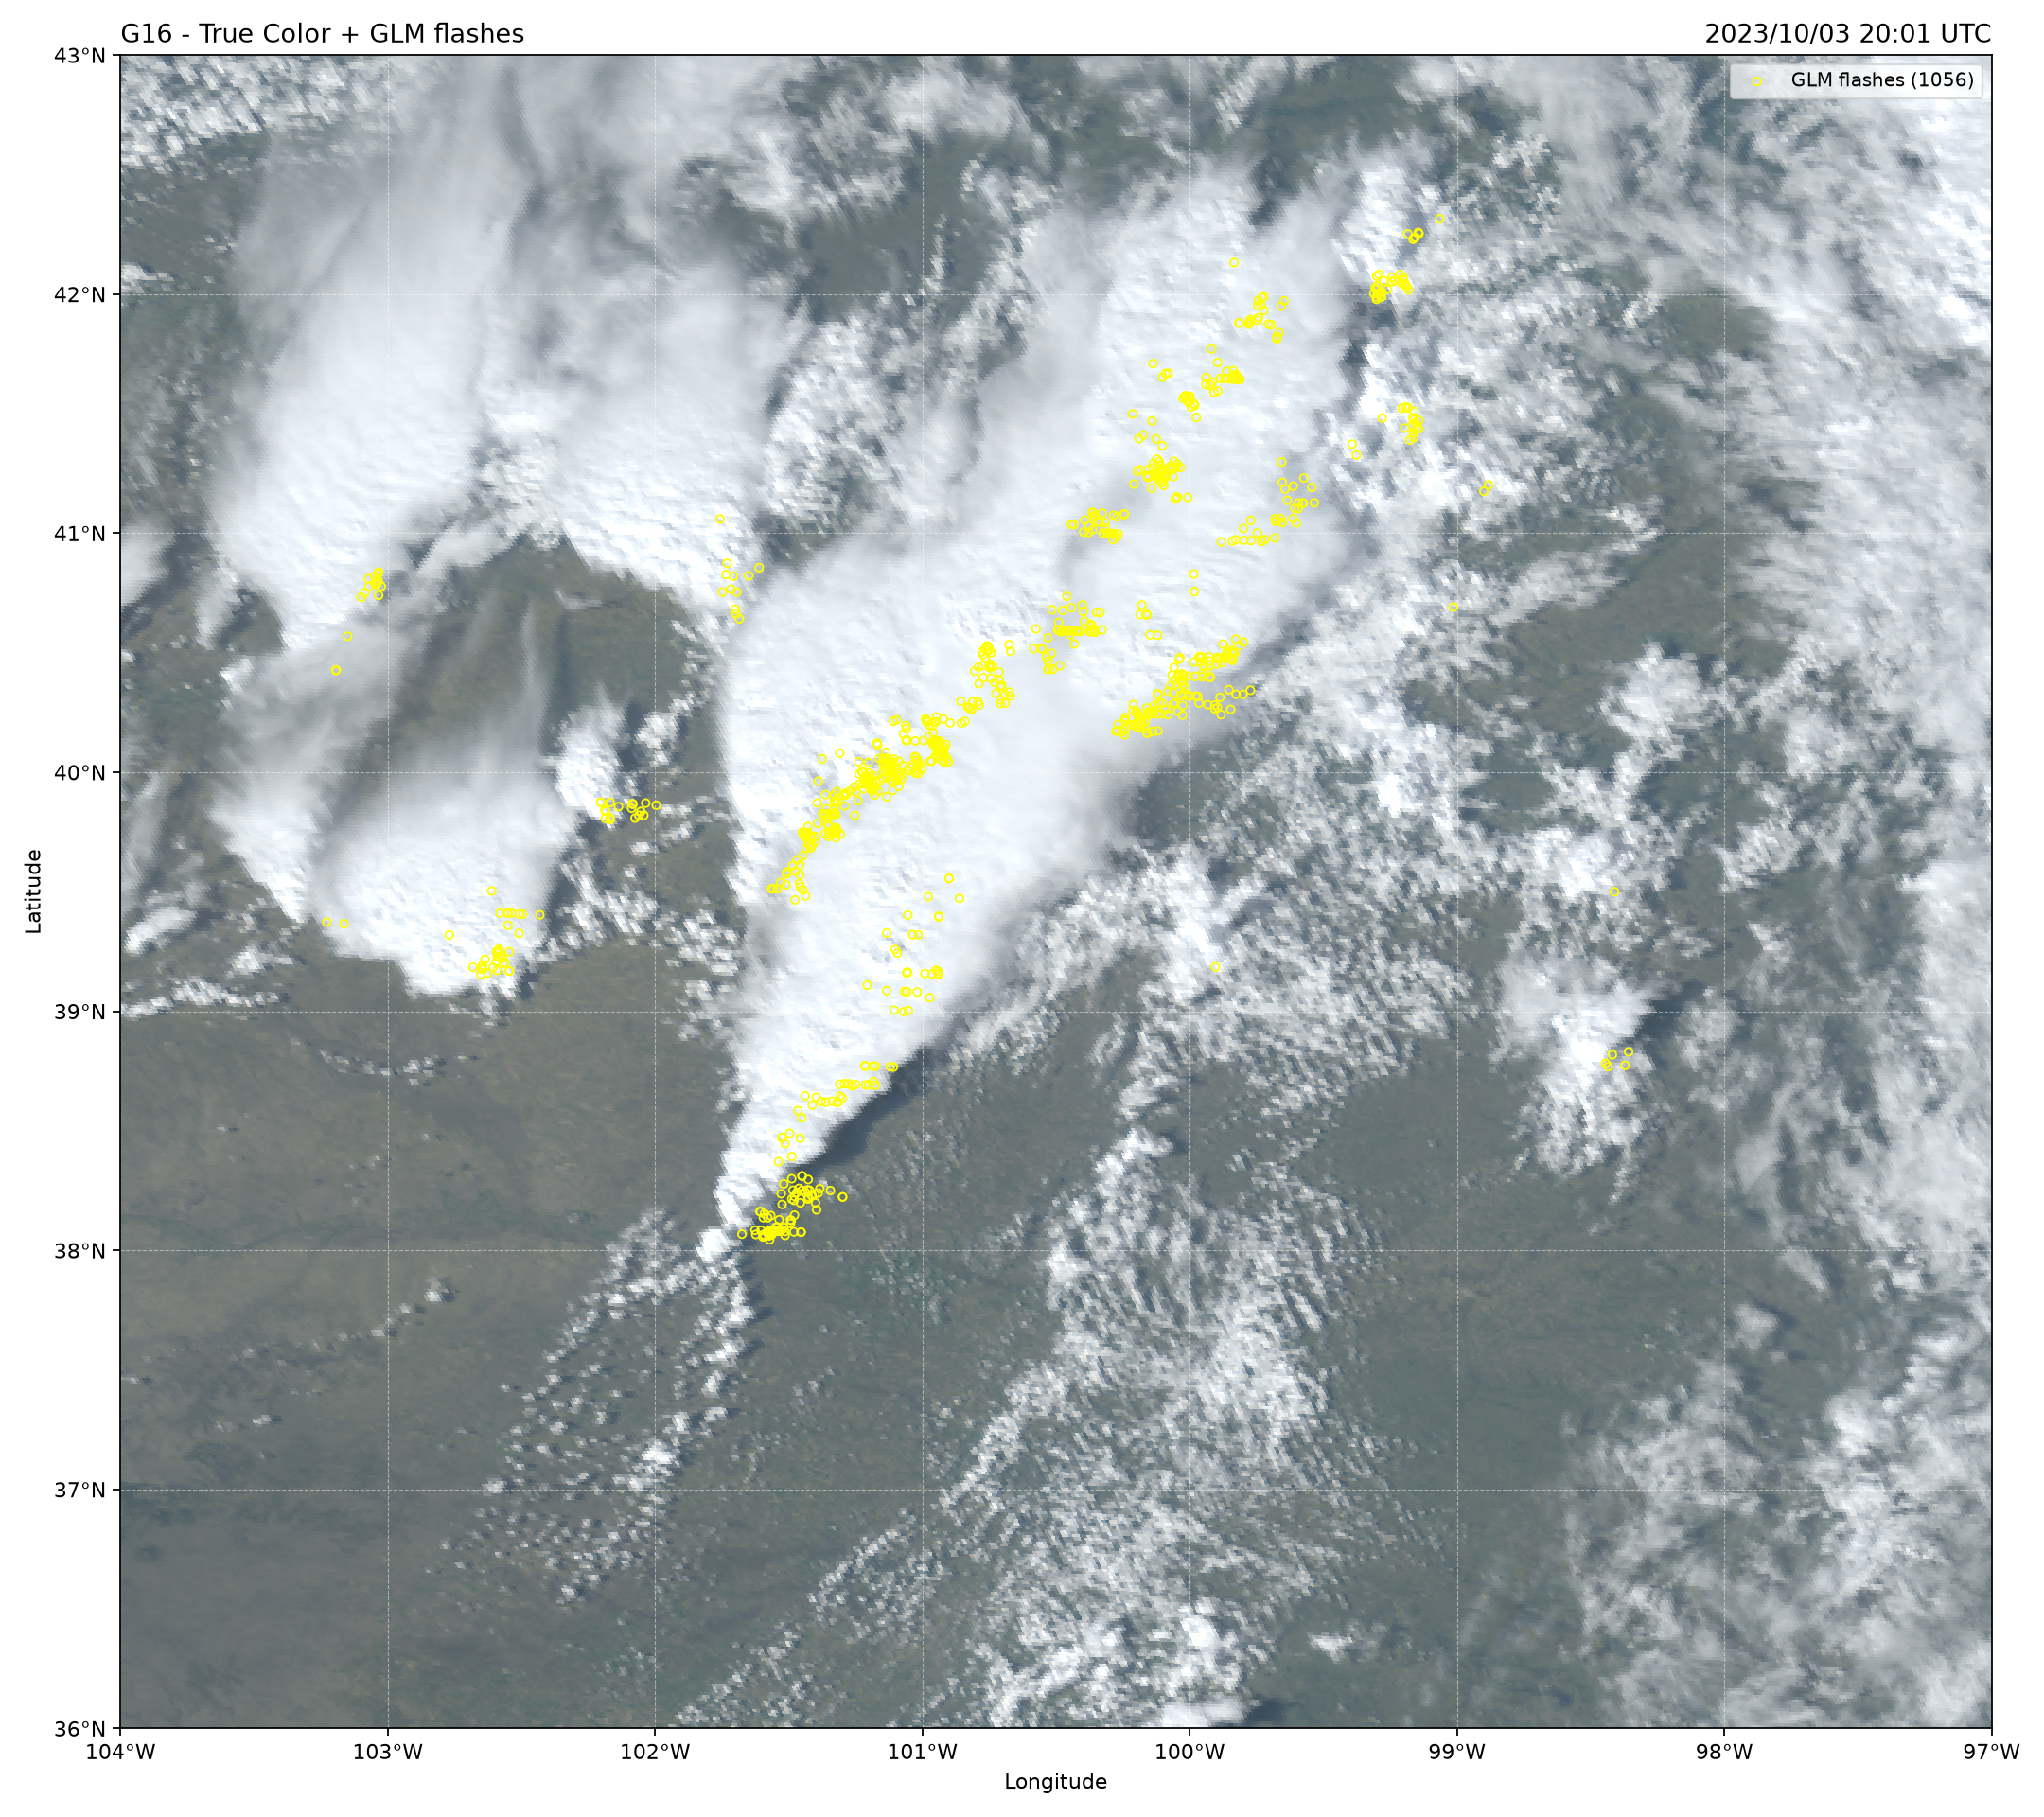

In [8]:
OUT = Path("../output/glm_true_color.png")
OUT.parent.mkdir(parents=True, exist_ok=True)

rgb = gt.true_color(abi_files, lon_min, lon_max, lat_min, lat_max)

fig, ax = figure_for(lon_min, lon_max, lat_min, lat_max)
gt.draw_rgb(ax, rgb)
ax.scatter(flash_lon, flash_lat, s=FLASH_SIZE, marker="o",
           facecolors="none", edgecolors=FLASH_COLOUR, linewidths=FLASH_EDGE,
           zorder=5, label=f"GLM flashes ({len(flash_lon)})")
ax.legend(loc="upper right", framealpha=0.7, fontsize=9)
decorate(ax, lon_min, lon_max, lat_min, lat_max,
         "G16 - True Color + GLM flashes", rgb.time)
fig.tight_layout(); fig.savefig(OUT, dpi=DPI); plt.close(fig)
display(Image(filename=str(OUT)))


## Notes

* GLM sees the flash at **cloud top**, so the points sit over the anvil rather
  than at the ground strike point. That they land on the bright convective tops
  is the check that the geolocation lines up.
* Detection efficiency falls towards the edge of the disk and at high latitude,
  which matters for volcanic lightning at Alaskan latitudes.